In [1]:
import pandas as pd
import numpy as np
import re
import math
from urllib.parse import urlparse
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load CSV file
df = pd.read_csv('dataset/datasetnew.csv')
print(f"✅ Dataset loaded: {len(df)} rows")
print(f"📊 Columns: {df.columns.tolist()}")
print(f"\n📈 Status Distribution:\n{df['status'].value_counts()}")


✅ Dataset loaded: 19431 rows
📊 Columns: ['Unnamed: 0', 'url', 'status']

📈 Status Distribution:
status
legitimate    9716
phishing      9715
Name: count, dtype: int64


In [3]:
# =========================
# ENTROPY FUNCTION
# =========================
def entropy(text):
    if not text:
        return 0
    prob = [count / len(text) for count in Counter(text).values()]
    return -sum(p * math.log2(p) for p in prob if p > 0)

# =========================
# TRUSTED DOMAIN
# =========================
trusted_domains = [
    "google.com", "youtube.com",
    "facebook.com", "instagram.com",
    "shopee.co.id", "tokopedia.com"
]

# =========================
# PHISHING KEYWORDS
# =========================
phishing_keywords = [
    "login", "verify", "update", "secure",
    "account", "bank", "confirm", "password"
]

# =========================
# FEATURE EXTRACTION (18 FEATURES)
# =========================
def extract_features(url):
    try:
        parsed = urlparse(str(url))
        domain = parsed.netloc.lower()
        path = parsed.path.lower()
        query = parsed.query.lower()

        # 1. URL Length
        url_length = len(str(url))

        # 2. Has IP Address
        has_ip_address = 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}', str(url)) else 0

        # 3. Dot Count in Domain
        dot_count = domain.count('.')

        # 4. HTTPS Flag
        https_flag = 1 if parsed.scheme == "https" else 0

        # 5. URL Entropy
        url_entropy = entropy(str(url))

        # 6. Token Count
        tokens = re.split(r'[./\-?=&]', str(url))
        token_count = len([t for t in tokens if t])

        # 7. Subdomain Count
        parts = domain.split('.')
        subdomain_count = max(len(parts) - 2, 0)

        # 8. Query Parameter Count
        query_param_count = len(query.split('&')) if query else 0

        # 9. TLD Length
        tld = parts[-1] if parts else ""
        tld_length = len(tld)

        # 10. Path Length
        path_length = len(parsed.path)

        # 11. Has Hyphen in Domain
        has_hyphen_in_domain = 1 if "-" in domain else 0

        # 12. Number of Digits
        number_of_digits = sum(c.isdigit() for c in str(url))

        # 13. TLD Popularity
        popular_tlds = ["com", "org", "net", "id", "co", "io"]
        tld_popularity = 1 if tld in popular_tlds else 0

        # 14. Suspicious File Extension
        suspicious_file_extension = 1 if parsed.path.endswith((".php", ".exe", ".zip", ".js")) else 0

        # 15. Domain Name Length
        domain_name_length = len(domain)

        # 16. Percentage Numeric Characters
        percentage_numeric_chars = number_of_digits / url_length if url_length > 0 else 0

        # 17. Has Phishing Keyword
        url_lower = str(url).lower()
        has_phishing_keyword = 1 if any(k in url_lower for k in phishing_keywords) else 0

        # 18. Is Trusted Domain
        is_trusted_domain = 1 if any(domain.endswith(td) for td in trusted_domains) else 0

        return [
            url_length, has_ip_address, dot_count, https_flag,
            url_entropy, token_count, subdomain_count, query_param_count,
            tld_length, path_length, has_hyphen_in_domain, number_of_digits,
            tld_popularity, suspicious_file_extension, domain_name_length,
            percentage_numeric_chars, has_phishing_keyword, is_trusted_domain
        ]
    except Exception as e:
        # Return default values if error
        return [0]*18

In [4]:
# %% [markdown]
# ## 4. Ekstraksi Fitur untuk Semua URL

print("🔄 Mengekstrak fitur dari URLs...")

# Apply feature extraction ke setiap URL
features_list = df['url'].apply(extract_features)

# Convert list of lists ke DataFrame
feature_names = [
    'url_length', 'has_ip_address', 'dot_count', 'https_flag',
    'url_entropy', 'token_count', 'subdomain_count', 'query_param_count',
    'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits',
    'tld_popularity', 'suspicious_file_extension', 'domain_name_length',
    'percentage_numeric_chars', 'has_phishing_keyword', 'is_trusted_domain'
]

features_df = pd.DataFrame(features_list.tolist(), columns=feature_names)

# Gabungkan dengan label
df_final = pd.concat([features_df, df['status']], axis=1)

# Convert label ke numeric (phishing=1, legitimate=0)
df_final['label'] = df_final['status'].map({'phishing': 1, 'legitimate': 0})

print(f"✅ Fitur berhasil diekstrak!")
print(f"📊 Shape dataset: {df_final.shape}")
print(f"\n📋 Kolom fitur:\n{feature_names}")

🔄 Mengekstrak fitur dari URLs...
✅ Fitur berhasil diekstrak!
📊 Shape dataset: (19431, 20)

📋 Kolom fitur:
['url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'has_phishing_keyword', 'is_trusted_domain']


In [ ]:
# %% [markdown]
# ## 5. Preview Data

print("\n🔍 Preview 5 baris pertama:")
display(df_final.head())

print(f"\n📈 Label Distribution:\n{df_final['label'].value_counts()}")


🔍 Preview 5 baris pertama:


,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,has_phishing_keyword,is_trusted_domain,status,label
0,46,0,2,0,4.615422,8,1,1,3,10,0,5,1,0,20,0.108696,0,0,phishing,1
1,128,0,10,0,4.568665,12,9,0,3,1,0,7,1,0,120,0.054688,0,0,phishing,1
2,52,0,2,0,4.192678,7,1,0,3,20,0,0,1,0,25,0.000000,0,0,phishing,1
3,21,0,2,0,3.653757,4,1,0,3,1,0,3,1,0,13,0.142857,0,0,legitimate,0
4,28,0,2,1,4.012188,4,1,0,3,1,0,0,1,0,19,0.000000,0,0,legitimate,0



📈 Label Distribution:
label
0    9716
1    9715
Name: count, dtype: int64


In [9]:
# Tentukan nama file
filename = 'dataset/owndataset.csv'

# Save ke CSV
df_final.to_csv(filename, index=False, encoding='utf-8')

# Konfirmasi
print(f"✅ File berhasil disimpan: {filename}")

✅ File berhasil disimpan: dataset/owndataset.csv


In [10]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

In [12]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("dataset/owndataset.csv")

# =========================
# LABEL
# 0 = legitimate, 1 = phishing
# =========================
y = df["classlabel"]


In [13]:
# =========================
# FEATURE ENGINEERING
# =========================
from feature_extraction import extract_features

X = []
for url in df["url"]:
    X.append(extract_features(url))

feature_names = [
    "url_length","has_ip_address","dot_count","https_flag","url_entropy",
    "token_count","subdomain_count","query_param_count",
    "tld_length","path_length","has_hyphen_in_domain",
    "number_of_digits","tld_popularity","suspicious_file_extension",
    "domain_name_length","percentage_numeric_chars",
    "has_phishing_keyword","is_trusted_domain"
]

X = pd.DataFrame(X, columns=feature_names)

In [14]:
print(df["classlabel"].isnull().sum())

0


In [15]:
df = df.dropna(subset=["classlabel"])

In [16]:
X = []
y = df["classlabel"]

# safety check
print("NaN label:", y.isnull().sum())

NaN label: 0


In [18]:
# =========================
# CLEAN DATA (IMPORTANT)
# =========================
df = df.dropna(subset=["classlabel"])
df = df.dropna(subset=["url"])

df["classlabel"] = pd.to_numeric(df["classlabel"], errors="coerce")
df = df.dropna(subset=["classlabel"])
df["classlabel"] = df["classlabel"].astype(int)

y = df["classlabel"]

In [19]:
df = df.dropna(subset=["url", "classlabel"])
df = df.reset_index(drop=True)

In [20]:
X = []
y = []

for i, url in enumerate(df["url"]):
    try:
        feat = extract_features(url)

        # validasi fitur tidak None
        if feat is None:
            continue

        X.append(feat)
        y.append(df["classlabel"].iloc[i])

    except Exception as e:
        print(f"Error URL: {url} -> {e}")

In [21]:
y = pd.Series(y)

In [22]:
print("X length:", len(X))
print("y length:", len(y))

X length: 19431
y length: 19431


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
# =========================================================
# 1. RANDOM FOREST (MAIN MODEL - CONTROL OVERFITTING)
# =========================================================
rf = RandomForestClassifier(
    n_estimators=700,
    max_depth=15,          # lebih kecil dari sebelumnya
    min_samples_split=2,  # diperbesar
    min_samples_leaf=1,    # diperbesar
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=700, random_state=42)

In [44]:
# =========================
# EVALUATION FUNCTION
# =========================
def evaluate(model, name):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"\n===== {name} =====")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print(classification_report(y_test, model.predict(X_test)))

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(model, param_dist, cv=5, n_iter=10, n_jobs=-1)
search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [ ]:

rf.fit(X_train, y_train)

In [45]:
evaluate(rf, "Random Forest")


===== Random Forest =====
Train Accuracy: 0.9456657598705978
Test Accuracy: 0.9001715265866209
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      2915
           1       0.92      0.87      0.90      2915

    accuracy                           0.90      5830
   macro avg       0.90      0.90      0.90      5830
weighted avg       0.90      0.90      0.90      5830



In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print(scores.mean())

0.9238840528512571


In [47]:
joblib.dump(rf, "model/rf_modelowdataset.pkl")

['model/rf_modelowdataset.pkl']

In [48]:
# =========================================================
# 2. DECISION TREE (BASELINE)
# =========================================================
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42)

In [49]:
# =========================================================
# 3. LOGISTIC REGRESSION (LINEAR BASELINE)
# =========================================================
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [50]:
evaluate(dt, "Decision Tree")
evaluate(lr, "Logistic Regression")


===== Decision Tree =====
Train Accuracy: 0.8433938680979339
Test Accuracy: 0.8222984562607204
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      2915
           1       0.85      0.79      0.82      2915

    accuracy                           0.82      5830
   macro avg       0.82      0.82      0.82      5830
weighted avg       0.82      0.82      0.82      5830


===== Logistic Regression =====
Train Accuracy: 0.7699433865156974
Test Accuracy: 0.760548885077187
              precision    recall  f1-score   support

           0       0.72      0.84      0.78      2915
           1       0.81      0.68      0.74      2915

    accuracy                           0.76      5830
   macro avg       0.77      0.76      0.76      5830
weighted avg       0.77      0.76      0.76      5830



In [58]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=700, random_state=42)

In [60]:
y_pred = rf.predict(X_test)

In [61]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2698  217]
 [ 365 2550]]


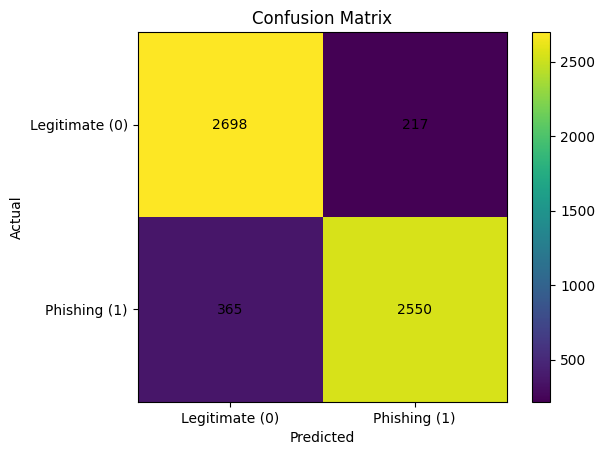

In [62]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([1,0], ["Phishing (1)", "Legitimate (0)"])
plt.yticks([1,0], ["Phishing (1)", "Legitimate (0)"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()